In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# загрузка данных

df = pd.read_excel(
    "Данные_для_курсовои_Классическое_МО.xlsx"
)

# просмотр данных

print(df.head().iloc[:, :4])

print(df.shape)

   Unnamed: 0    IC50, mM    CC50, mM         SI
0           0    6.239374  175.482382  28.125000
1           1    0.771831    5.402819   7.000000
2           2  223.808778  161.142320   0.720000
3           3    1.705624  107.855654  63.235294
4           4  107.131532  139.270991   1.300000
(1001, 214)


Датасет содержит 1001 химическое соединение и 214 признаков. Из них 3 являются целевыми переменными (IC50, CC50 и SI), остальные представляют собой молекулярные дескрипторы.

In [ ]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

,0
MaxPartialCharge,3
MinPartialCharge,3
MaxAbsPartialCharge,3
MinAbsPartialCharge,3
BCUT2D_MWHI,3
BCUT2D_MWLOW,3
BCUT2D_CHGHI,3
BCUT2D_CHGLO,3
BCUT2D_LOGPHI,3
BCUT2D_LOGPLOW,3


In [ ]:
df = df.fillna(df.median())


In [ ]:
print("Основные статистики:")
print(df.describe().iloc[:, :4])


Основные статистики:
        Unnamed: 0     IC50, mM     CC50, mM            SI
count  1001.000000  1001.000000  1001.000000   1001.000000
mean    500.000000   222.805156   589.110728     72.508823
std     289.108111   402.169734   642.867508    684.482739
min       0.000000     0.003517     0.700808      0.011489
25%     250.000000    12.515396    99.999036      1.433333
50%     500.000000    46.585183   411.039342      3.846154
75%     750.000000   224.975928   894.089176     16.566667
max    1000.000000  4128.529377  4538.976189  15620.600000


Признак: IC50, mM
Коэффициент асимметрии: 3.6694195575400603


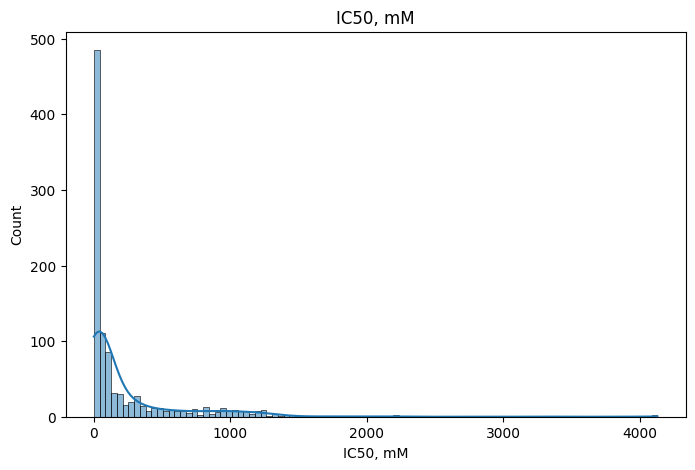

Признак: CC50, mM
Коэффициент асимметрии: 1.970374675189377


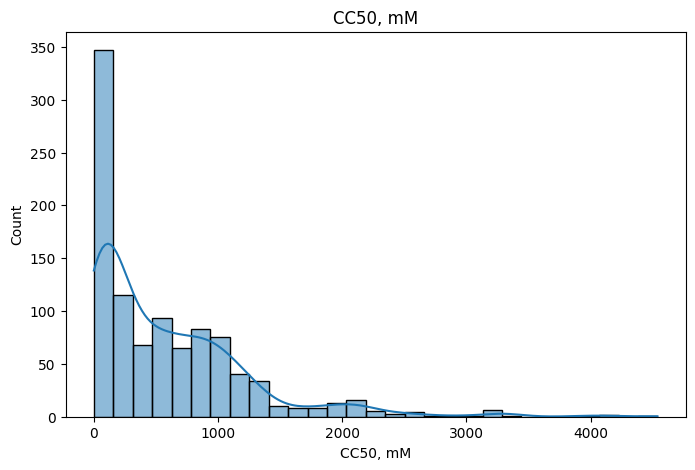

Признак: SI
Коэффициент асимметрии: 17.986197518634345


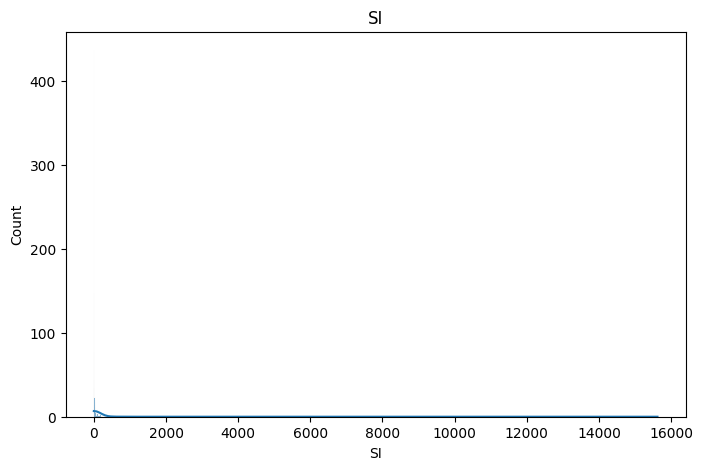

In [ ]:
targets = [
    "IC50, mM",
    "CC50, mM",
    "SI"
]

for column in targets:

    print("Признак:", column)

    value = skew(df[column].dropna())

    print("Коэффициент асимметрии:", value)

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title(column)

    plt.show()

Распределения всех целевых переменных имеют выраженную правостороннюю асимметрию.

Большинство соединений имеют относительно небольшие значения показателей, однако присутствует небольшое количество объектов с очень высокими значениями, формирующими длинный правый хвост распределения.

Интересно, что распределение SI имеет очень высокую положительную асимметрию - 17.99. Скорее всего этого говорит о наличии небольшого числа соединений с исключительно высоким индексом селективности. Также судя по графику большая часть оси X вообще пуста, что говорит о частых экстремальных значениях

Для уменьшения влияния выбросов и нормализации распределения целевых переменных целесообразно рассмотреть логарифмическое преобразование

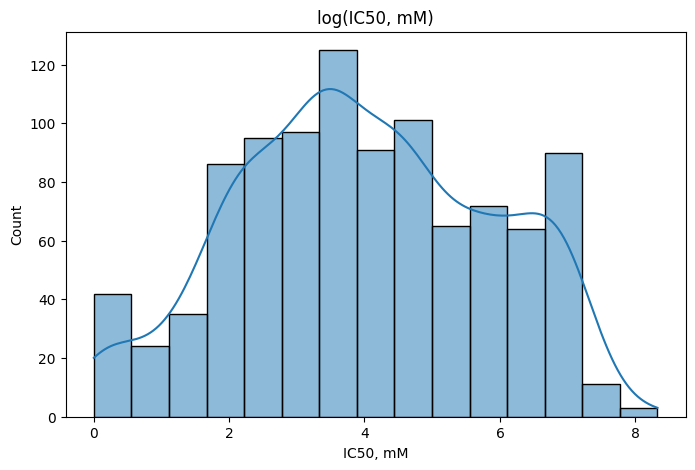

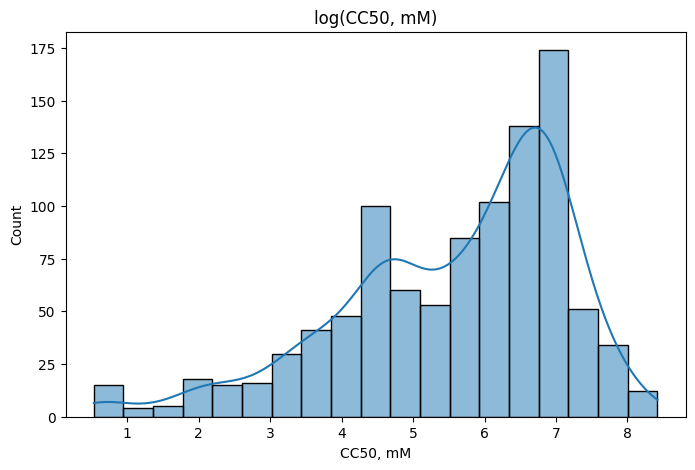

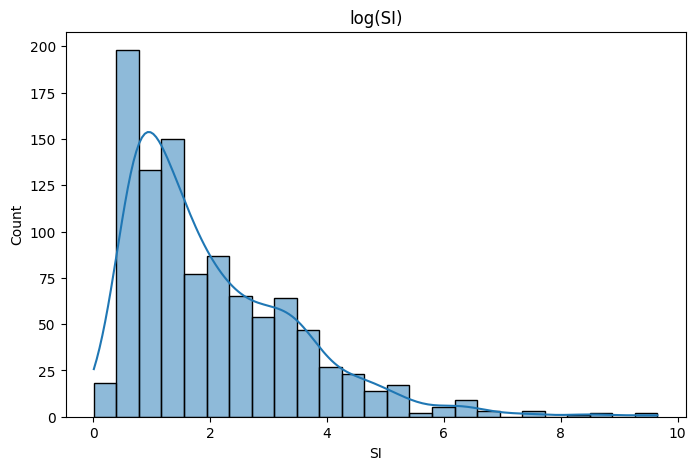

In [ ]:
for column in targets:

    plt.figure(figsize=(8,5))

    sns.histplot(
        np.log1p(df[column]),
        kde=True
    )

    plt.title(f"log({column})")

    plt.show()

Для IC50 после логарифмирования распределение приняло колоколообразный вид еще с небольшими ассиметриям но все же умеренный вид который стал близок к нормальному. Распределение CC50 стало лучше всего похоже на нормальноое. SI не смогло прийти к нормальному виду (или близко схожему с ним как в первом случае) даже после логарифмирования. В таком случае действительно существуют распределения с необычно высоким SI

Практически во всех источниках указана такая формула для SI:

SI = CC50/IC50

То есть индекс селективности показывает отношение токсичности(CC50) к противовирусной активности(IC50). Высокий SI считается признаком перспективного лекарственного кандидата

Таким образом выдвенем гипотезу:



SI должен уменьшаться при росте IC50


SI должен расти при росте CC50


<Axes: xlabel='IC50, mM', ylabel='SI'>

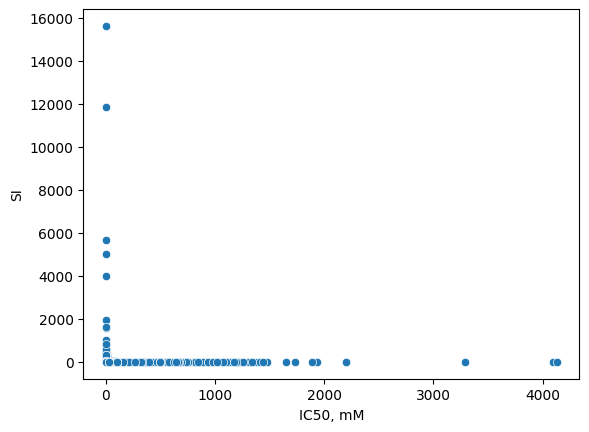

In [ ]:
sns.scatterplot(
    data=df,
    x="IC50, mM",
    y="SI"
)

<Axes: xlabel='CC50, mM', ylabel='SI'>

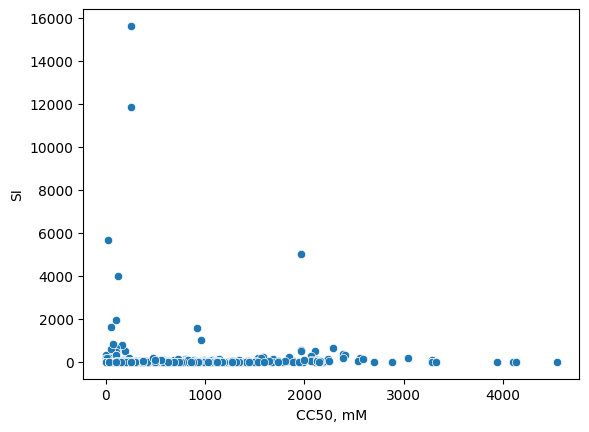

In [ ]:
sns.scatterplot(
    data=df,
    x="CC50, mM",
    y="SI"
)

Кажется, что обе гипотезы подтверждаются лишь частино. Самые большие значения SI (4000–16000) встречаются только при очень малых IC50, при увеличении CC50 лишь на небольшие значения, SI также постепенно растет от 4000 до 16000. Дальше идет более нелинейная связь с увеличением CC50, SI также растет но лишь при крайнем значении равном 2000, далее SI резко падает. Т.е при малых значениях CC50 и IC50 связь действительно подтверждается.  

Посчитаем корреляции между значениями

In [ ]:
df[["IC50, mM", "CC50, mM", "SI"]].corr("spearman")

,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.621412,-0.642760
"CC50, mM",0.621412,1.000000,0.099757
SI,-0.642760,0.099757,1.000000


Наша SI получается связана гораздо сильнее с IC50, чем с CC50. Другими словами, различия в эффективности соединений (IC50) оказывают намного большее влияние на селективность, чем различия в токсичности (CC50)


Также интересно отметить слабую связь или практически ее отсутствие у CC50 с SI. То есть изменчивость SI определяется не просто в большей степени значениями IC50, а преимущественно лишь ими



Последнее что стоит отметить - это довольно высокая положительная связь IC50 с CC50(0.621412). Так соединения с высоким IC50 часто имеют высокий CC50 и наоборот. Вероятно можно говорить о неком компромиссе между противовирусной активностью и токсичностью исследуемых соединений. При этом как уже упоминалось полученный результат позволяет предположить, что основным фактором, определяющим селективность соединений(SI), все же является противовирусная активность(IC50), а не токсичность(CC50)

В рамках дальнейшего исследования проанализируем сами химические дескрипторы


In [ ]:
target_table = (df.corr("spearman", numeric_only=True)["SI"].abs())
target_corr = target_table.sort_values(ascending=False)
print(target_corr.head(15))

SI                          1.000000
IC50, mM                    0.642760
fr_Imine                    0.216453
MaxEStateIndex              0.200892
MaxAbsEStateIndex           0.200892
NumSaturatedCarbocycles     0.200845
MinEStateIndex              0.195659
FractionCSP3                0.191442
SMR_VSA4                    0.189550
NumAliphaticCarbocycles     0.188778
NumSaturatedHeterocycles    0.183711
VSA_EState8                 0.182660
SMR_VSA7                    0.179795
VSA_EState1                 0.174734
NumAliphaticHeterocycles    0.171212
Name: SI, dtype: float64


После IC50 идёт очень резкий обрыв. Тем не менее мы видим, что последующие данные так или иначе лишь с немного угасающей силой, но все же связаны с селективностью. Если брать после IC50 то мы можем видеть сразу 4 признака с коэфицентами спирмана > 0.2. Тем не менее ни у одного последующего признака после IC50 нету связи с SI больше чем 0.25

Ранее упоминалось, что величина IC50 более всего влияет на SI(в отличие от CC50). Посмотрим как другие коэфиценты связаны с IC50

In [ ]:
target_table = (df.corr("spearman", numeric_only=True)["IC50, mM"].abs())
target_corr = target_table.sort_values(ascending=False)
print(target_corr.head(15))
print('\n')

IC50, mM                    1.000000
SI                          0.642760
CC50, mM                    0.621412
NumSaturatedHeterocycles    0.277862
SlogP_VSA5                  0.270496
VSA_EState4                 0.259461
NumAliphaticCarbocycles     0.245072
fr_NH2                      0.242980
VSA_EState8                 0.238564
PEOE_VSA7                   0.228182
NumAliphaticHeterocycles    0.223751
EState_VSA8                 0.218501
SMR_VSA5                    0.212524
BCUT2D_MWLOW                0.212363
EState_VSA5                 0.208685
Name: IC50, mM, dtype: float64




Химические дескрипторы демонстрируют более сильную связь с IC50, чем с SI. Это может объясняться тем, что SI является производным показателем, рассчитываемым через IC50, вследствие чего его зависимость от отдельных молекулярных характеристик оказывается более сложной.

И наконец посмотрим дескрипторы для CC50

In [ ]:
target_corr_cc50 = (df.corr(method="spearman", numeric_only=True)["CC50, mM"].abs()
                    .sort_values(ascending=False))
print(target_corr_cc50.head(15))

CC50, mM               1.000000
IC50, mM               0.621412
Kappa2                 0.302849
Kappa3                 0.299059
Kappa1                 0.293032
MolMR                  0.283132
Chi1v                  0.279799
Chi0v                  0.278131
NumValenceElectrons    0.277745
Chi0                   0.277594
Chi1n                  0.276383
LabuteASA              0.276046
Chi0n                  0.275572
PEOE_VSA7              0.275317
Unnamed: 0             0.270993
Name: CC50, mM, dtype: float64


Вообще в целом, как можно видеть есть отдельные тенденции, однако пока ни один отдельный дескриптор не способен хорошо объяснить значения IC50, CC50 и SI вместе. Получается в наших данных присутствуют более сложные закономерности. В таком случае используем случайный лес, чтобы возможно суметь уловить их

In [ ]:
from sklearn.ensemble import RandomForestRegressor


targets = ["IC50, mM", "CC50, mM", "SI"]

X = df.drop(columns=targets)

X = X.select_dtypes(include=np.number)

X = X.fillna(X.median())
X = X.drop(columns=["Unnamed: 0"])  #далее во всех трех случаях присутствует индекс который наверняка случайно попадает в датасет, удаляем его


y = np.log1p(df["SI"])


rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)

rf.fit(X, y)


importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)



print(importance.head(20))

               feature  importance
101        VSA_EState6    0.089142
103        VSA_EState8    0.053490
21        BCUT2D_CHGLO    0.030393
105       FractionCSP3    0.030333
4                  qed    0.029935
25        BCUT2D_MRLOW    0.024507
41       HallKierAlpha    0.020185
20        BCUT2D_CHGHI    0.017354
22       BCUT2D_LOGPHI    0.017206
99         VSA_EState4    0.016813
23      BCUT2D_LOGPLOW    0.015078
19        BCUT2D_MWLOW    0.015061
42                 Ipc    0.014812
27            BalabanJ    0.014269
68            SMR_VSA7    0.014090
33               Chi1n    0.013989
26              AvgIpc    0.013859
2    MinAbsEStateIndex    0.013682
100        VSA_EState5    0.013250
24         BCUT2D_MRHI    0.013030


In [ ]:
y = np.log1p(df["IC50, mM"])
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)

rf.fit(X, y)

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)




print(importance.head(20))

                 feature  importance
103          VSA_EState8    0.113673
99           VSA_EState4    0.068390
101          VSA_EState6    0.035983
123              MolLogP    0.032992
25          BCUT2D_MRLOW    0.026437
20          BCUT2D_CHGHI    0.021741
116           NumHDonors    0.021582
107            NHOHCount    0.019959
15      FpDensityMorgan1    0.016768
78            SlogP_VSA5    0.015447
90           EState_VSA5    0.015258
4                    qed    0.015126
100          VSA_EState5    0.014855
37                 Chi3n    0.014180
19          BCUT2D_MWLOW    0.013416
2      MinAbsEStateIndex    0.012980
13   MaxAbsPartialCharge    0.012763
17      FpDensityMorgan3    0.012526
26                AvgIpc    0.012416
58             PEOE_VSA7    0.011981


In [ ]:
y = np.log1p(df["CC50, mM"])
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)

rf.fit(X, y)

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)



print(importance.head(20))

              feature  importance
107         NHOHCount    0.058091
19       BCUT2D_MWLOW    0.055087
25       BCUT2D_MRLOW    0.031804
44             Kappa2    0.028278
103       VSA_EState8    0.028047
43             Kappa1    0.027138
123           MolLogP    0.026844
101       VSA_EState6    0.025131
45             Kappa3    0.024298
99        VSA_EState4    0.020515
58          PEOE_VSA7    0.019448
5                 SPS    0.019384
21       BCUT2D_CHGLO    0.018274
57          PEOE_VSA6    0.014417
135            fr_C_O    0.013968
15   FpDensityMorgan1    0.013369
26             AvgIpc    0.013106
22      BCUT2D_LOGPHI    0.012948
100       VSA_EState5    0.012292
24        BCUT2D_MRHI    0.012022


Анализ важности признаков по случайному лесу выявил сразу несколько признаков которые стабильно важны сразу для нескольких целей:



VSA_EState4, VSA_EState6, VSA_EState8, MolLogP(CC50 и IC50), qed(IC50 и SI) и BCUT2D_MRLOW


Также было решено включить признаки NumSaturatedHeterocycles, NumAliphaticCarbocycles, NumSaturatedCarbocycles. Несмотря на то, что они отсутствуют среди важных признаков для случайного леса, мы ранее неоднократно видели при анализе Спирмана, что эти коэфиценты часто находились в топах среди IC50 и SI. Т.к уже было обговорено, что IC50 влияет на SI даже сильнее, чем CC50, было тем более решено их оставить           

Итого у нас 9 признаков. Подобные признаки мы могли наблюдать и в корреляционном анализе ранее. Данные признаки наряду с 3 основными будут для нас в дальнейшем представлять наибольший интерес при построении моделей для наибольшего качества эффективности потенциального лекарства